Dataset Shape: (5819, 8)

Cluster Summary (KMeans):
                 Recency  Frequency  Monetary  AvgOrderValue  \
KMeans_Cluster                                                 
0               5.534306   1.167720  6.787278       6.056593   
1               3.256429   1.564669  6.746696       5.458911   
2               5.644883   0.901698  5.181638       4.850266   
3               3.113815   2.608436  8.537380       6.020248   

                Hierarchical_Cluster  DBSCAN_Cluster  GMM_Cluster  
KMeans_Cluster                                                     
0                           1.939863       -0.000573     1.491409  
1                           1.397652       -0.001467     1.391783  
2                           1.431867       -0.005768     1.795242  
3                           0.019652       -0.008314     2.763416  


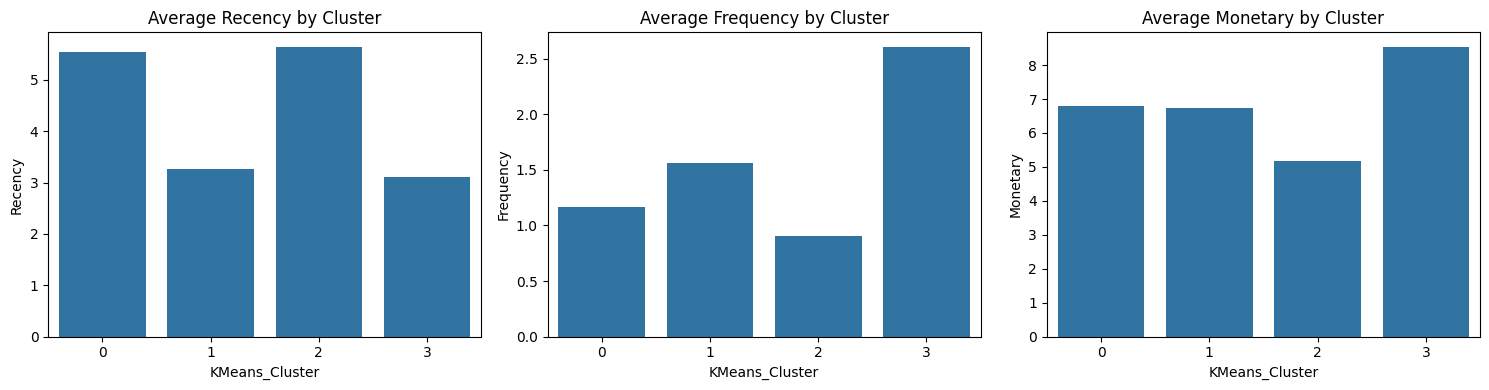


Customer Segment Distribution:
Customer_Segment
At-Risk Customers           2433
High Value Customers        2282
Low Engagement Customers     961
Regular Customers            143
Name: count, dtype: int64

Business Strategy Suggestions:

Segment: At-Risk Customers
Strategy: Send re-engagement emails, personalized offers, and limited-time promotions.

Segment: High Value Customers
Strategy: Offer loyalty rewards, exclusive discounts, and premium membership programs.

Segment: Low Engagement Customers
Strategy: Increase marketing campaigns, awareness programs, and entry-level discounts.

Segment: Regular Customers
Strategy: Maintain regular communication and occasional promotional offers.

Business Insights Notebook Completed Successfully.


In [1]:
# ==========================================
# BUSINESS INSIGHTS & CUSTOMER SEGMENTATION
# ==========================================

# -------------------------------
# 1. Import Libraries
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 2. Load Clustered Data
# -------------------------------
rfm_clusters = pd.read_csv("../data/processed/rfm_with_clusters.csv", index_col=0)

print("Dataset Shape:", rfm_clusters.shape)
rfm_clusters.head()

# ==========================================
# 3. Analyze KMeans Clusters (Best Model)
# ==========================================

# Compute average RFM values per cluster
cluster_summary = rfm_clusters.groupby("KMeans_Cluster").mean()

print("\nCluster Summary (KMeans):")
print(cluster_summary)

# Save summary
cluster_summary.to_csv("../results/kmeans_cluster_summary.csv")

# ==========================================
# 4. Visualize Cluster Characteristics
# ==========================================

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.barplot(x=cluster_summary.index, y=cluster_summary['Recency'])
plt.title("Average Recency by Cluster")

plt.subplot(1,3,2)
sns.barplot(x=cluster_summary.index, y=cluster_summary['Frequency'])
plt.title("Average Frequency by Cluster")

plt.subplot(1,3,3)
sns.barplot(x=cluster_summary.index, y=cluster_summary['Monetary'])
plt.title("Average Monetary by Cluster")

plt.tight_layout()
plt.show()

# ==========================================
# 5. Assign Business Labels
# ==========================================

def assign_segment(row):
    if row['Monetary'] > cluster_summary['Monetary'].mean() and row['Frequency'] > cluster_summary['Frequency'].mean():
        return "High Value Customers"
    elif row['Recency'] > cluster_summary['Recency'].mean():
        return "At-Risk Customers"
    elif row['Frequency'] < cluster_summary['Frequency'].mean():
        return "Low Engagement Customers"
    else:
        return "Regular Customers"

rfm_clusters['Customer_Segment'] = rfm_clusters.apply(assign_segment, axis=1)

# Check distribution
print("\nCustomer Segment Distribution:")
print(rfm_clusters['Customer_Segment'].value_counts())

# ==========================================
# 6. Business Recommendations
# ==========================================

segment_counts = rfm_clusters['Customer_Segment'].value_counts()

print("\nBusiness Strategy Suggestions:\n")

for segment in segment_counts.index:
    print(f"Segment: {segment}")
    
    if segment == "High Value Customers":
        print("Strategy: Offer loyalty rewards, exclusive discounts, and premium membership programs.\n")
        
    elif segment == "At-Risk Customers":
        print("Strategy: Send re-engagement emails, personalized offers, and limited-time promotions.\n")
        
    elif segment == "Low Engagement Customers":
        print("Strategy: Increase marketing campaigns, awareness programs, and entry-level discounts.\n")
        
    else:
        print("Strategy: Maintain regular communication and occasional promotional offers.\n")

# ==========================================
# 7. Save Final Dataset
# ==========================================

rfm_clusters.to_csv("../results/final_customer_segments.csv")

print("Business Insights Notebook Completed Successfully.")